In [45]:
import arcpy
import os

# ==========================================
# 1. 參數設定區
# ==========================================
t1_layer = "OL_P1_2204_coral_Simplify"     # T1 圖層
t2_layer = "OL_P1_2209_cor_SimplifyPolyg"  # T2 圖層

f_t1_id = "ID"
f_t1_temp = "Temp_ID"
f_t1_fate = "Fate"
f_t1_area = "Shape_Area"
f_t1_ramet = "Ramet"  

f_t2_id = "ID"               # 輸出目標：LONG
f_t2_temp = "Temp_ID"        
f_t2_old_id = "Old_ID"       # 輸出目標：TEXT
f_t2_old_fate = "Old_Fate"   # 輸出目標：TEXT
f_t2_recruit = "Recruit"     # 輸出目標：TEXT

# ==========================================
# 2. 解析 T1 資料 (Domain 轉換與 Ramet 拆解)
# ==========================================
print("正在讀取 T1 資料並解析 Ramet 與 Domain...")

fate_map = {}
desc_t1 = arcpy.Describe(t1_layer)
workspace = desc_t1.path
while workspace and not (workspace.endswith(".gdb") or workspace.endswith(".sde")):
    workspace = os.path.dirname(workspace)

if workspace:
    target_domain = next((f.domain for f in desc_t1.fields if f.name == f_t1_fate), None)
    if target_domain:
        fate_map = next((d.codedValues for d in arcpy.da.ListDomains(workspace) if d.name == target_domain), {})



t1_lookup = {}    
ramet_lookup = {} 

with arcpy.da.SearchCursor(t1_layer, [f_t1_temp, f_t1_id, f_t1_fate, f_t1_area, f_t1_ramet]) as cursor:
    for row in cursor:
        uid = int(row[1]) if row[1] is not None else 0
        raw_fate = row[2]
        fate = str(fate_map.get(raw_fate, raw_fate)).strip() if raw_fate is not None else "Unknown"
        area = row[3] if row[3] else 0
        ramet_val = str(row[4]).strip() if row[4] else ""
        
        rec = {"id": uid, "fate": fate, "area": area}

        # --- A. Fi 邏輯：拆解 Ramet 字串 ---
        if "-" in ramet_val:
            try:
                parts = [int(p) for p in ramet_val.split("-") if p.strip().isdigit()]
                for p in parts:
                    ramet_lookup[p] = rec
            except Exception:
                pass
        
        # --- B. 一般繼承索引 ---
        if row[0] is not None:
            tid = int(row[0])
            if tid not in t1_lookup:
                t1_lookup[tid] = []
            t1_lookup[tid].append(rec)

# ==========================================
# 3. 強制變更 T2 欄位格式 (刪除後重建)
# ==========================================
print("正在管理 T2 欄位結構...")

# 檢查並處理 ID 欄位
existing_fields = [f.name.lower() for f in arcpy.ListFields(t2_layer)]

if f_t2_id.lower() in existing_fields:
    print(f"  - 偵測到舊有 {f_t2_id} 欄位，正在刪除以更換格式...")
    arcpy.DeleteField_management(t2_layer, f_t2_id)

print(f"  - 正在建立 LONG 格式的 {f_t2_id} 欄位...")
arcpy.AddField_management(t2_layer, f_t2_id, "LONG")

# 建立其餘輔助欄位 (TEXT 格式)
def add_text_field(layer, field_name, length):
    if field_name.lower() not in [f.name.lower() for f in arcpy.ListFields(layer)]:
        arcpy.AddField_management(layer, field_name, "TEXT", field_length=length)
        print(f"  - 新增欄位: {field_name}")

add_text_field(t2_layer, f_t2_old_id, 100)
add_text_field(t2_layer, f_t2_old_fate, 50)
add_text_field(t2_layer, f_t2_recruit, 5)

# ==========================================
# 4. 執行 T2 屬性更新
# ==========================================
print("正在執行更新與比對...")

stats = {"G_S": 0, "Fi": 0, "Fu": 0, "Recruit": 0, "Others": 0}
others_details = []

update_fields = [f_t2_temp, f_t2_id, f_t2_old_id, f_t2_old_fate, f_t2_recruit]

with arcpy.da.UpdateCursor(t2_layer, update_fields) as cursor:
    for row in cursor:
        t2_temp_raw = row[0]
        t2_temp = int(t2_temp_raw) if t2_temp_raw is not None else None
        
        new_id, old_id_val, old_fate_val, recruit_val = None, None, None, "N"
        
        # 判定優先級 1: Ramet 分裂 (Fi)
        if t2_temp in ramet_lookup:
            res = ramet_lookup[t2_temp]
            new_id = res["id"]
            old_id_val = str(res["id"])
            old_fate_val = "Fi"
            stats["Fi"] += 1
            
        # 判定優先級 2: 一般對應
        elif t2_temp in t1_lookup:
            records = t1_lookup[t2_temp]
            primary_fate = records[0]["fate"]
            
            if primary_fate in ["G", "S"]:
                new_id = records[0]["id"]
                old_fate_val = primary_fate
                stats["G_S"] += 1
            elif primary_fate == "Fu":
                max_rec = max(records, key=lambda x: x['area'])
                new_id = max_rec['id']
                old_id_val = "+".join(sorted(list(set(str(r["id"]) for r in records))))
                old_fate_val = "Fu"
                stats["Fu"] += 1
            else:
                new_id = records[0]["id"]
                old_fate_val = primary_fate
                stats["Others"] += 1
                others_details.append({"T2_ID": new_id, "T1_ID": records[0]["id"], "Fate": primary_fate})
        
        # 判定優先級 3: Recruit
        else:
            new_id = t2_temp 
            recruit_val = "Y"
            old_fate_val = "Recruit"
            stats["Recruit"] += 1
            
        row[1] = new_id  # 此處為整數，將存入 LONG
        row[2] = old_id_val
        row[3] = old_fate_val
        row[4] = recruit_val
        cursor.updateRow(row)

# ==========================================
# 5. 輸出統計報告
# ==========================================
total_t2 = sum(stats.values())



print("-" * 50)
print(f"{'Fate Category':<18} | {'Count':<8} | {'Percentage':<10}")
print("-" * 50)

if total_t2 > 0:
    for label, key in [("Growth/Shrink", "G_S"), ("Fission (Fi)", "Fi"), 
                       ("Fusion (Fu)", "Fu"), ("Recruitment", "Recruit"), ("Others", "Others")]:
        count = stats[key]
        # 使用 LaTeX 表示百分比公式
        # $$Percentage = (\frac{Count}{Total\_T2}) \times 100$$
        perc = (count / total_t2) * 100
        print(f"{label:<18} | {count:<8} | {perc:>8.2f}%")
    
    print("-" * 50)
    print(f"{'Total T2 Polygons':<18} | {total_t2:<8} | {'100.00%':<10}")
    
    if others_details:
        print("\n⚠️ Others 詳細清單:")
        for item in others_details:
            print(f"T2 ID: {item['T2_ID']} | 來源 T1 ID: {item['T1_ID']} | Fate: {item['Fate']}")
else:
    print("無資料可供統計。")

正在讀取 T1 資料並解析 Ramet 與 Domain...
正在管理 T2 欄位結構...
  - 偵測到舊有 ID 欄位，正在刪除以更換格式...
  - 正在建立 LONG 格式的 ID 欄位...
正在執行更新與比對...
--------------------------------------------------
Fate Category      | Count    | Percentage
--------------------------------------------------
Growth/Shrink      | 711      |    58.14%
Fission (Fi)       | 276      |    22.57%
Fusion (Fu)        | 94       |     7.69%
Recruitment        | 142      |    11.61%
Others             | 0        |     0.00%
--------------------------------------------------
Total T2 Polygons  | 1223     | 100.00%   


正在分析資料並篩選超過 5.0 cm 的個體...
-----------------------------------------------------------------
📊 新生個體尺寸分析報告：門檻直徑 > 5.0 cm
📏 面積門檻值：0.001963 m²
-----------------------------------------------------------------
● 新生個體總數 (Total)     : 142
● 超過門檻數量 (Count)     : 22
● 數量佔比 (Percentage)    : 15.49%
-----------------------------------------------------------------
💡 超過 5.0 cm 的詳細個體清單：
ID              | Shape_Area (m²)     
----------------------------------------
1049            | 0.006022            
327             | 0.006002            
790             | 0.004526            
797             | 0.004345            
1079            | 0.004260            
800             | 0.004152            
446             | 0.003894            
82              | 0.003790            
870             | 0.003546            
991             | 0.003111            
975             | 0.002938            
918             | 0.002878            
1076            | 0.002741            
631             | 0.002512          

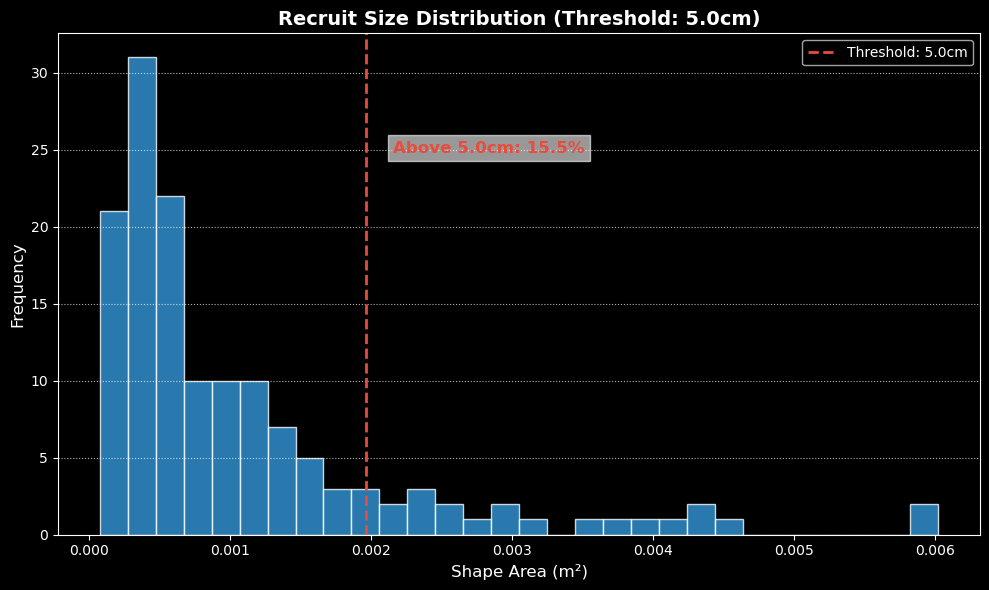

-----------------------------------------------------------------


In [46]:
import arcpy
import math
import matplotlib.pyplot as plt

# ==========================================
# 🧭 1. 參數設定區 (調整這裡，下方全自動同步)
# ==========================================
t2_layer = "OL_P1_2209_cor_SimplifyPolyg" 

# 修改此數值 (單位: 公分)，清單與圖表將同步更新
target_diameter_cm = 5.0 

f_id = "ID"
f_recruit = "Recruit"
f_area = "Shape_Area"

# ==========================================
# 2. 自動計算門檻
# ==========================================
target_radius_m = (target_diameter_cm / 100) / 2
area_threshold = math.pi * (target_radius_m ** 2)

# ==========================================
# 3. 數據提取
# ==========================================
print(f"正在分析資料並篩選超過 {target_diameter_cm} cm 的個體...")

recruit_areas = []
large_recruits_data = [] # 儲存符合條件的 (ID, Area)

fields = [f_id, f_area]
where_clause = f"{f_recruit} = 'Y'"

with arcpy.da.SearchCursor(t2_layer, fields, where_clause) as cursor:
    for row in cursor:
        uid = row[0]
        area = row[1]
        recruit_areas.append(area)
        
        if area > area_threshold:
            large_recruits_data.append((uid, area))

total_count = len(recruit_areas)
large_count = len(large_recruits_data)

# ==========================================
# 4. 動態統計報告
# ==========================================
print("-" * 65)
print(f"📊 新生個體尺寸分析報告：門檻直徑 > {target_diameter_cm} cm")
print(f"📏 面積門檻值：{area_threshold:.6f} m²")
print("-" * 65)

if total_count > 0:
    percentage = (large_count / total_count) * 100
    
    print(f"● 新生個體總數 (Total)     : {total_count}")
    print(f"● 超過門檻數量 (Count)     : {large_count}")
    print(f"● 數量佔比 (Percentage)    : {percentage:.2f}%")
    print("-" * 65)
    
    # --- 新增：列出所有超過門檻的 ID 與 面積 ---
    if large_count > 0:
        print(f"💡 超過 {target_diameter_cm} cm 的詳細個體清單：")
        print(f"{'ID':<15} | {'Shape_Area (m²)':<20}")
        print("-" * 40)
        # 依照面積從大到小排序後顯示
        large_recruits_data.sort(key=lambda x: x[1], reverse=True)
        
        for rid, rarea in large_recruits_data:
            print(f"{rid:<15} | {rarea:<20.6f}")
    else:
        print(f"✅ 沒有偵測到直徑超過 {target_diameter_cm} cm 的新生個體。")
    
    print("-" * 65)
    
    # ==========================================
    # 5. 繪圖可視化
    # ==========================================
    plt.figure(figsize=(10, 6))
    counts, bins, _ = plt.hist(recruit_areas, bins=30, color='#3498db', edgecolor='white', alpha=0.8)
    
    # 動態紅色門檻線
    plt.axvline(area_threshold, color='#e74c3c', linestyle='--', linewidth=2, 
                label=f'Threshold: {target_diameter_cm}cm')
    
    plt.title(f'Recruit Size Distribution (Threshold: {target_diameter_cm}cm)', fontsize=14, fontweight='bold')
    plt.xlabel('Shape Area (m²)', fontsize=12)
    plt.ylabel('Frequency', fontsize=12)
    plt.legend()
    
    # 標記百分比
    plt.text(area_threshold * 1.1, max(counts) * 0.8, 
             f'Above {target_diameter_cm}cm: {percentage:.1f}%', 
             color='#e74c3c', fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.6))

    plt.grid(axis='y', linestyle=':', alpha=0.7)
    plt.tight_layout()
    plt.show()

else:
    print(f"⚠️ 找不到標記為 Recruit ('Y') 的資料。")

print("-" * 65)